# Linear Regression Competition

### Guidelines and advice

* When you send in your final code, the judges should be able to run everything top to bottom without getting any errors. 
<br>
<br>
* Understanding the columns and how they relate to your dependent variable is key to building a good Linear Regression model. Make sure you have a solid understanding of how your data is distributed.
<br>
<br>
* You'll need to drop a lot of columns to reduce complexity. Consider dropping columns where more than 90% of the data points is the same value. Garbage in, garbage out!
<br>
<br>
* You'll need to reshape object columns to numeric values. If the column is categorical and likely nominal, you should turn the data into dummies. If it represent ordinal data, you should map out numerical values for each text value. And finally, if the column has too many unique values, you should drop it.
<br>
<br>
* Remember to scale the data, but don't scale your dummy variables.
<br>
<br>
* Only variables with a p-value below 5% are allowed in your competing model. You can see p-values in `result.summary()`.
<br>
<br>
* You'll need to make sure you don't have the multicolinearity. You can see multicolinearity warning in `result.summary()`.
<br>
<br>
* You are not allowed to drop any rows from that dataset.
<br>
<br>
* The score we are competing for is Adj. R-squared, which means that you'll get punished for having too many independent variables.
<br>
<br>
* We will look at your code at 4:30 PM today! Bonne Chance!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
pd.options.display.max_rows = 500
pd.options.display.max_columns = 500

In [2]:
df = pd.read_csv("housing_prices.csv")

In [3]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
#dropping all cols that are more than 10% missing
df = df.dropna(axis=1, thresh=len(df) * 0.9)

#droping id as it is unique 
df = df.drop(columns=["Id"])

#droping columns that are 90% or more dominant
to_drop = [i for i in df.columns if df[i].value_counts().max() > len(df) * .9]
df = df.drop(columns=to_drop)



In [6]:
df_bak = df 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 55 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotArea        1460 non-null   int64  
 3   LotShape       1460 non-null   str    
 4   LandContour    1460 non-null   str    
 5   LotConfig      1460 non-null   str    
 6   Neighborhood   1460 non-null   str    
 7   Condition1     1460 non-null   str    
 8   BldgType       1460 non-null   str    
 9   HouseStyle     1460 non-null   str    
 10  OverallQual    1460 non-null   int64  
 11  OverallCond    1460 non-null   int64  
 12  YearBuilt      1460 non-null   int64  
 13  YearRemodAdd   1460 non-null   int64  
 14  RoofStyle      1460 non-null   str    
 15  Exterior1st    1460 non-null   str    
 16  Exterior2nd    1460 non-null   str    
 17  MasVnrArea     1452 non-null   float64
 18  ExterQual      1460

In [7]:
num_df = df.select_dtypes(include="number")
corr = num_df.corr()

pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= 0.75:
            pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

for i in pairs:
    stat1, stat2, corre = i
    print(stat1,"and",stat2,"are correlated by",corre)

OverallQual and SalePrice are correlated by 0.7909816005838054
YearBuilt and GarageYrBlt are correlated by 0.8256674841743404
TotalBsmtSF and 1stFlrSF are correlated by 0.8195299750050339
GrLivArea and TotRmsAbvGrd are correlated by 0.8254893743088424
GarageCars and GarageArea are correlated by 0.8824754142814619


In [8]:
#droping values that are redundant
df = df.drop(columns= ["GarageYrBlt","1stFlrSF","GarageArea","TotRmsAbvGrd"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 51 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotArea        1460 non-null   int64  
 3   LotShape       1460 non-null   str    
 4   LandContour    1460 non-null   str    
 5   LotConfig      1460 non-null   str    
 6   Neighborhood   1460 non-null   str    
 7   Condition1     1460 non-null   str    
 8   BldgType       1460 non-null   str    
 9   HouseStyle     1460 non-null   str    
 10  OverallQual    1460 non-null   int64  
 11  OverallCond    1460 non-null   int64  
 12  YearBuilt      1460 non-null   int64  
 13  YearRemodAdd   1460 non-null   int64  
 14  RoofStyle      1460 non-null   str    
 15  Exterior1st    1460 non-null   str    
 16  Exterior2nd    1460 non-null   str    
 17  MasVnrArea     1452 non-null   float64
 18  ExterQual      1460

In [10]:
def nonnumerical(df):
    return df.select_dtypes(exclude="number")

In [11]:
missing_cols = df.columns[df.isna().any()]
print(missing_cols)


Index(['MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'GarageType', 'GarageFinish', 'GarageQual'],
      dtype='str')


In [12]:
to_clean = nonnumerical(df)

In [13]:
for i in to_clean:
    print(i)

MSZoning
LotShape
LandContour
LotConfig
Neighborhood
Condition1
BldgType
HouseStyle
RoofStyle
Exterior1st
Exterior2nd
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
HeatingQC
KitchenQual
GarageType
GarageFinish
GarageQual
SaleType
SaleCondition


In [14]:
#all values to bool
to_bool = []
for i in to_clean:
    if len(df[i].value_counts()) < 3:
        to_bool.append(i)

print(to_bool)
#nothing to bool here 

[]


In [15]:
#po = poor(0), Fa = Fair(1), TA = Typical,Average (2), Gd = Good(3), Ex = Excelent (4)
scale_dict = {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4}
df["HeatingQC"].value_counts()

HeatingQC
Ex    741
TA    428
Gd    241
Fa     49
Po      1
Name: count, dtype: int64

In [16]:
scale = {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5}

quality_cols = [
    i for i in to_clean
    if set(df[i].dropna().unique()).issubset(set(scale.keys()))
]
print(quality_cols)

['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'GarageQual']


In [17]:
type(to_clean)

pandas.DataFrame

In [18]:
for i in quality_cols:
    df[i] = df[i].map(scale).fillna(0)




In [19]:
for i in quality_cols:
    print(df[i].value_counts())

ExterQual
3    906
4    488
5     52
2     14
Name: count, dtype: int64
ExterCond
3    1282
4     146
2      28
5       3
1       1
Name: count, dtype: int64
BsmtQual
3.0    649
4.0    618
5.0    121
0.0     37
2.0     35
Name: count, dtype: int64
BsmtCond
3.0    1311
4.0      65
2.0      45
0.0      37
1.0       2
Name: count, dtype: int64
HeatingQC
5    741
3    428
4    241
2     49
1      1
Name: count, dtype: int64
KitchenQual
3    735
4    586
5    100
2     39
Name: count, dtype: int64
GarageQual
3.0    1311
0.0      81
2.0      48
4.0      14
5.0       3
1.0       3
Name: count, dtype: int64


In [20]:
to_clean = to_clean.drop(columns=quality_cols)

In [21]:
to_clean

,MSZoning,LotShape,LandContour,LotConfig,Neighborhood,Condition1,BldgType,HouseStyle,RoofStyle,Exterior1st,Exterior2nd,Foundation,BsmtExposure,BsmtFinType1,BsmtFinType2,GarageType,GarageFinish,SaleType,SaleCondition
0,RL,Reg,Lvl,Inside,CollgCr,Norm,1Fam,2Story,Gable,VinylSd,VinylSd,PConc,No,GLQ,Unf,Attchd,RFn,WD,Normal
1,RL,Reg,Lvl,FR2,Veenker,Feedr,1Fam,1Story,Gable,MetalSd,MetalSd,CBlock,Gd,ALQ,Unf,Attchd,RFn,WD,Normal
2,RL,IR1,Lvl,Inside,CollgCr,Norm,1Fam,2Story,Gable,VinylSd,VinylSd,PConc,Mn,GLQ,Unf,Attchd,RFn,WD,Normal
3,RL,IR1,Lvl,Corner,Crawfor,Norm,1Fam,2Story,Gable,Wd Sdng,Wd Shng,BrkTil,No,ALQ,Unf,Detchd,Unf,WD,Abnorml
4,RL,IR1,Lvl,FR2,NoRidge,Norm,1Fam,2Story,Gable,VinylSd,VinylSd,PConc,Av,GLQ,Unf,Attchd,RFn,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Reg,Lvl,Inside,Gilbert,Norm,1Fam,2Story,Gable,VinylSd,VinylSd,PConc,No,Unf,Unf,Attchd,RFn,WD,Normal
1456,RL,Reg,Lvl,Inside,NWAmes,Norm,1Fam,1Story,Gable,Plywood,Plywood,CBlock,No,ALQ,Rec,Attchd,Unf,WD,Normal
1457,RL,Reg,Lvl,Inside,Crawfor,Norm,1Fam,2Story,Gable,CemntBd,CmentBd,Stone,No,GLQ,Unf,Attchd,RFn,WD,Normal
1458,RL,Reg,Lvl,Inside,NAmes,Norm,1Fam,1Story,Hip,MetalSd,MetalSd,CBlock,Mn,GLQ,Rec,Attchd,Unf,WD,Normal


In [22]:
df["BsmtExposure"].value_counts(dropna=False)

BsmtExposure
No     953
Av     221
Gd     134
Mn     114
NaN     38
Name: count, dtype: int64

In [23]:
#scaling basement exposure

Bsmt_exposure_scale = {"No":0, "Mn":1, "Av":2, "Gd":3}

df["BsmtExposure"] = df["BsmtExposure"].map(Bsmt_exposure_scale).fillna(0)

df["BsmtExposure"].value_counts()

BsmtExposure
0.0    991
2.0    221
3.0    134
1.0    114
Name: count, dtype: int64

In [24]:
#scaling BsmtFinType1 and BsmtFinType2
BsmtFinType_scale = {"Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}


df["BsmtFinType1"] = df["BsmtFinType1"].map(BsmtFinType_scale).fillna(0)
df["BsmtFinType2"] = df["BsmtFinType2"].map(BsmtFinType_scale).fillna(0)

df["BsmtFinType1"].value_counts()

BsmtFinType1
1.0    430
6.0    418
5.0    220
4.0    148
3.0    133
2.0     74
0.0     37
Name: count, dtype: int64

In [25]:
df["BsmtFinType1"].value_counts()

BsmtFinType1
1.0    430
6.0    418
5.0    220
4.0    148
3.0    133
2.0     74
0.0     37
Name: count, dtype: int64

In [26]:
df["BsmtFinType2"].value_counts()

BsmtFinType2
1.0    1256
3.0      54
2.0      46
0.0      38
4.0      33
5.0      19
6.0      14
Name: count, dtype: int64

In [27]:
to_clean = to_clean.drop(columns=["BsmtExposure","BsmtFinType1","BsmtFinType2"])

In [28]:
#garage finish scaling
garage_finish_scale = {"Unf": 1, "RFn": 2, "Fin": 3}
df["GarageFinish"] = df["GarageFinish"].map(garage_finish_scale).fillna(0)

In [29]:
#lot shape scaling
lot_shape_scale = {"Reg": 0, "IR1": 1, "IR2": 2, "IR3": 3}
df["LotShape"] = df["LotShape"].map(lot_shape_scale)

In [30]:
to_clean = to_clean.drop(columns=["LotShape","GarageFinish"])

In [31]:
df_bak = df
to_clean

,MSZoning,LandContour,LotConfig,Neighborhood,Condition1,BldgType,HouseStyle,RoofStyle,Exterior1st,Exterior2nd,Foundation,GarageType,SaleType,SaleCondition
0,RL,Lvl,Inside,CollgCr,Norm,1Fam,2Story,Gable,VinylSd,VinylSd,PConc,Attchd,WD,Normal
1,RL,Lvl,FR2,Veenker,Feedr,1Fam,1Story,Gable,MetalSd,MetalSd,CBlock,Attchd,WD,Normal
2,RL,Lvl,Inside,CollgCr,Norm,1Fam,2Story,Gable,VinylSd,VinylSd,PConc,Attchd,WD,Normal
3,RL,Lvl,Corner,Crawfor,Norm,1Fam,2Story,Gable,Wd Sdng,Wd Shng,BrkTil,Detchd,WD,Abnorml
4,RL,Lvl,FR2,NoRidge,Norm,1Fam,2Story,Gable,VinylSd,VinylSd,PConc,Attchd,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Lvl,Inside,Gilbert,Norm,1Fam,2Story,Gable,VinylSd,VinylSd,PConc,Attchd,WD,Normal
1456,RL,Lvl,Inside,NWAmes,Norm,1Fam,1Story,Gable,Plywood,Plywood,CBlock,Attchd,WD,Normal
1457,RL,Lvl,Inside,Crawfor,Norm,1Fam,2Story,Gable,CemntBd,CmentBd,Stone,Attchd,WD,Normal
1458,RL,Lvl,Inside,NAmes,Norm,1Fam,1Story,Hip,MetalSd,MetalSd,CBlock,Attchd,WD,Normal


In [32]:
df["GarageType"] = df["GarageType"].fillna("None")

In [33]:
df.drop(["Exterior1st","Exterior2nd"],axis=1,inplace=True)
to_clean.drop(columns=["Exterior1st","Exterior2nd"], inplace=True)

In [34]:
df = pd.get_dummies(df, columns=to_clean.columns, drop_first=True)

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 120 entries, MSSubClass to SaleCondition_Partial
dtypes: bool(83), float64(8), int64(29)
memory usage: 540.5 KB


In [36]:
df.isna().sum()[df.isna().sum() > 0]

MasVnrArea    8
dtype: int64

In [37]:
#MasVnrArea still has missing values lets fill with mdeian
df["MasVnrArea"] = df["MasVnrArea"].fillna(df["MasVnrArea"].mean())
df.isna().sum()[df.isna().sum() > 0]
#FIXED

Series([], dtype: int64)

In [38]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.drop("SalePrice")
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [39]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]


In [40]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression

rfecv = RFECV(LinearRegression(), step=1, cv=5, scoring="r2")
rfecv.fit(X, y)

print("optimal number of features:", rfecv.n_features_)
selected = X.columns[rfecv.support_]
X = X[selected]
X.columns

optimal number of features: 110


Index(['MSSubClass', 'LotArea', 'LotShape', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'BsmtQual',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='str', length=110)

In [41]:
import statsmodels.api as sm

X = sm.add_constant(X)

def trimming_pct(X, y, pct):
    model = sm.OLS(y, X.astype(float)).fit()
    if len(model.pvalues[model.pvalues > pct]) > 0:
        worst = model.pvalues.idxmax()
        X = X.drop(columns=[worst])
        return trimming_pct(X, y, pct)
    else:
        return model

In [42]:


final_model = trimming_pct(X, y, 0.05)

    

In [43]:
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     206.5
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:15:58   Log-Likelihood:                -17066.
No. Observations:                1460   AIC:                         3.422e+04
Df Residuals:                    1414   BIC:                         3.447e+04
Df Model:                          45                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.342e+05   5290.778     25.369      0.000    1.24e+05    1.45e+05
MSSubClass           -4842.6044   1531.497     -3.162      0.002   -7846.855   -1838.354
LotArea               4034.9815    895.662      4.505      0.000    2278.013    5791.950
OverallQual           1.469e+04   1532.764      9.584      0.000    1.17e+04    1.77e+04
OverallCond           5210.8121    919.026      5.670      0.000    3408.011    7013.614
MasVnrArea            2182.2639    966.172      2.259      0.024     286.979    4077.549
ExterQual             3514.1351   1365.268      2.574      0.010     835.967    6192.304
BsmtQual              6250.7796   1528.533      4.089      0.000    3252.343    9249.216
BsmtCond             -3412.5467   1159.953     -2.942      0.003   -5687.960   -1137.133
BsmtExposure          7865.2669    963.060      8.167      0.000    5976.088    9754.446
BsmtFinType1          4865.8759   1061.395      4.584      0.000    2783.799    6947.953
2ndFlrSF              7507.7639   2392.199      3.138      0.002    2815.122    1.22e+04
GrLivArea             2.345e+04   1862.120     12.594      0.000    1.98e+04    2.71e+04
BsmtFullBath          3229.8868   1023.742      3.155      0.002    1221.670    5238.104
FullBath              3544.0176   1252.123      2.830      0.005    1087.799    6000.236
HalfBath              3148.8548   1125.278      2.798      0.005     941.461    5356.248
BedroomAbvGr         -2420.1178   1086.259     -2.228      0.026   -4550.971    -289.264
KitchenQual           5818.4611   1234.526      4.713      0.000    3396.761    8240.161
Fireplaces            3473.2129    961.774      3.611      0.000    1586.556    5359.870
GarageCars            8207.1880   1324.604      6.196      0.000    5608.787    1.08e+04
GarageQual            5690.9530   2425.847      2.346      0.019     932.308    1.04e+04
WoodDeckSF            1761.7614    846.549      2.081      0.038     101.135    3422.388
LandContour_HLS       1.383e+04   5342.908      2.589      0.010    3352.475    2.43e+04
LandContour_Lvl       1.028e+04   3298.107      3.117      0.002    3809.672    1.67e+04
LotConfig_CulDSac     1.121e+04   3255.203      3.445      0.001    4828.613    1.76e+04
Neighborhood_BrDale   2.819e+04   9092.906      3.100      0.002    1.04e+04     4.6e+04
Neighborhood_BrkSide  1.395e+04   4278.160      3.262      0.001    5561.584    2.23e+04
Neighborhood_Crawfor  2.582e+04   4627.751      5.579      0.000    1.67e+04    3.49e+04
Neighborhood_MeadowV  1.881e+04   8175.819      2.301      0.022    2776.338    3.49e+04
Neighborhood_NPkVill   2.41e+04   1.06e+04      2.264      0.024    3215.429     4.5e+04
Neighborhood_NoRidge  4.818e+04   5375.220      8.964      0.000    3.76e+04    5.87e+04
Neighborhood_NridgHt   5.03e+04   4317.048     11.651    

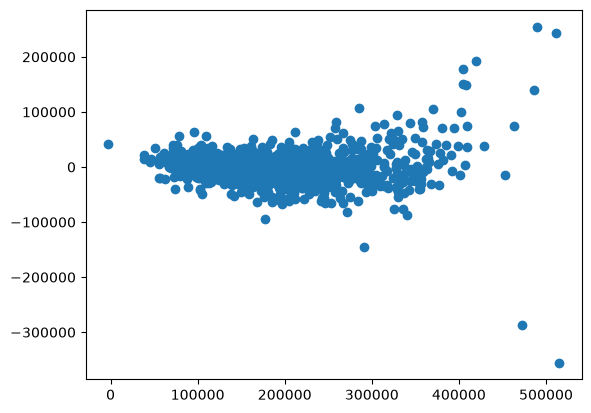

In [44]:
import matplotlib.pyplot as plt
plt.scatter(final_model.fittedvalues, final_model.resid)

https://library.virginia.edu/data/articles/interpreting-log-transformations-in-a-linear-model

https://library.virginia.edu/data/articles/interpreting-log-transformations-in-a-linear-model

In [45]:
df["SalePrice"] = np.log(df["SalePrice"])

In [46]:
df["TotalSF"] = df["TotalBsmtSF"] + df["2ndFlrSF"] + df["GrLivArea"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

In [47]:
to_drop =["TotalBsmtSF","2ndFlrSF","GrLivArea","YrSold","YearBuilt","YearRemodAdd","YrSold"]
df.drop(columns=to_drop,inplace=True)

In [48]:
X = df.drop(columns=["SalePrice"])
X = sm.add_constant(X)
y = df["SalePrice"]
final_model_2 = trimming_pct(X, y, 0.05)

In [49]:
final_model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     248.8
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:15:59   Log-Likelihood:                 963.64
No. Observations:                1460   AIC:                            -1821.
Df Residuals:                    1407   BIC:                            -1541.
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   11.3643      0.049    232.732      0.000      11.268      11.460
MSSubClass              -0.0266      0.004     -6.258      0.000      -0.035      -0.018
LotArea                  0.0125      0.004      3.088      0.002       0.005       0.020
OverallQual              0.0823      0.007     12.446      0.000       0.069       0.095
OverallCond              0.0440      0.004     10.938      0.000       0.036       0.052
BsmtQual                 0.0205      0.006      3.253      0.001       0.008       0.033
BsmtExposure             0.0201      0.004      4.841      0.000       0.012       0.028
BsmtFinType1             0.0230      0.005      4.278      0.000       0.012       0.034
BsmtFinSF1              -0.0183      0.007     -2.471      0.014      -0.033      -0.004
BsmtUnfSF               -0.0169      0.007     -2.526      0.012      -0.030      -0.004
HeatingQC                0.0184      0.004      4.276      0.000       0.010       0.027
BsmtFullBath             0.0212      0.005      4.381      0.000       0.012       0.031
FullBath                 0.0280      0.006      5.071      0.000       0.017       0.039
HalfBath                 0.0205      0.005      4.116      0.000       0.011       0.030
BedroomAbvGr             0.0189      0.005      4.069      0.000       0.010       0.028
KitchenQual              0.0211      0.005      4.097      0.000       0.011       0.031
Fireplaces               0.0245      0.004      5.854      0.000       0.016       0.033
GarageFinish             0.0150      0.005      2.942      0.003       0.005       0.025
GarageCars               0.0522      0.006      9.065      0.000       0.041       0.063
GarageQual               0.0364      0.011      3.406      0.001       0.015       0.057
WoodDeckSF               0.0101      0.004      2.732      0.006       0.003       0.017
MSZoning_FV              0.4209      0.055      7.643      0.000       0.313       0.529
MSZoning_RH              0.4371      0.054      8.117      0.000       0.331       0.543
MSZoning_RL              0.4272      0.044      9.788      0.000       0.342       0.513
MSZoning_RM              0.3595      0.044      8.194      0.000       0.273       0.446
LandContour_HLS          0.0752      0.026      2.941      0.003       0.025       0.125
LandContour_Low          0.0769      0.030      2.536      0.011       0.017       0.136
LandContour_Lvl          0.0668      0.017      3.824      0.000       0.033       0.101
LotConfig_CulDSac        0.0449      0.014      3.138      0.002       0.017       0.073
LotConfig_FR2           -0.0396      0.020     -2.022      0.043      -0.078      -0.001
Neighborhood_ClearCr     0.0722      0.028      2.602      0.009       0.018       0.127
Neighborhood_Crawfor     0.1469      0.020      7.203    

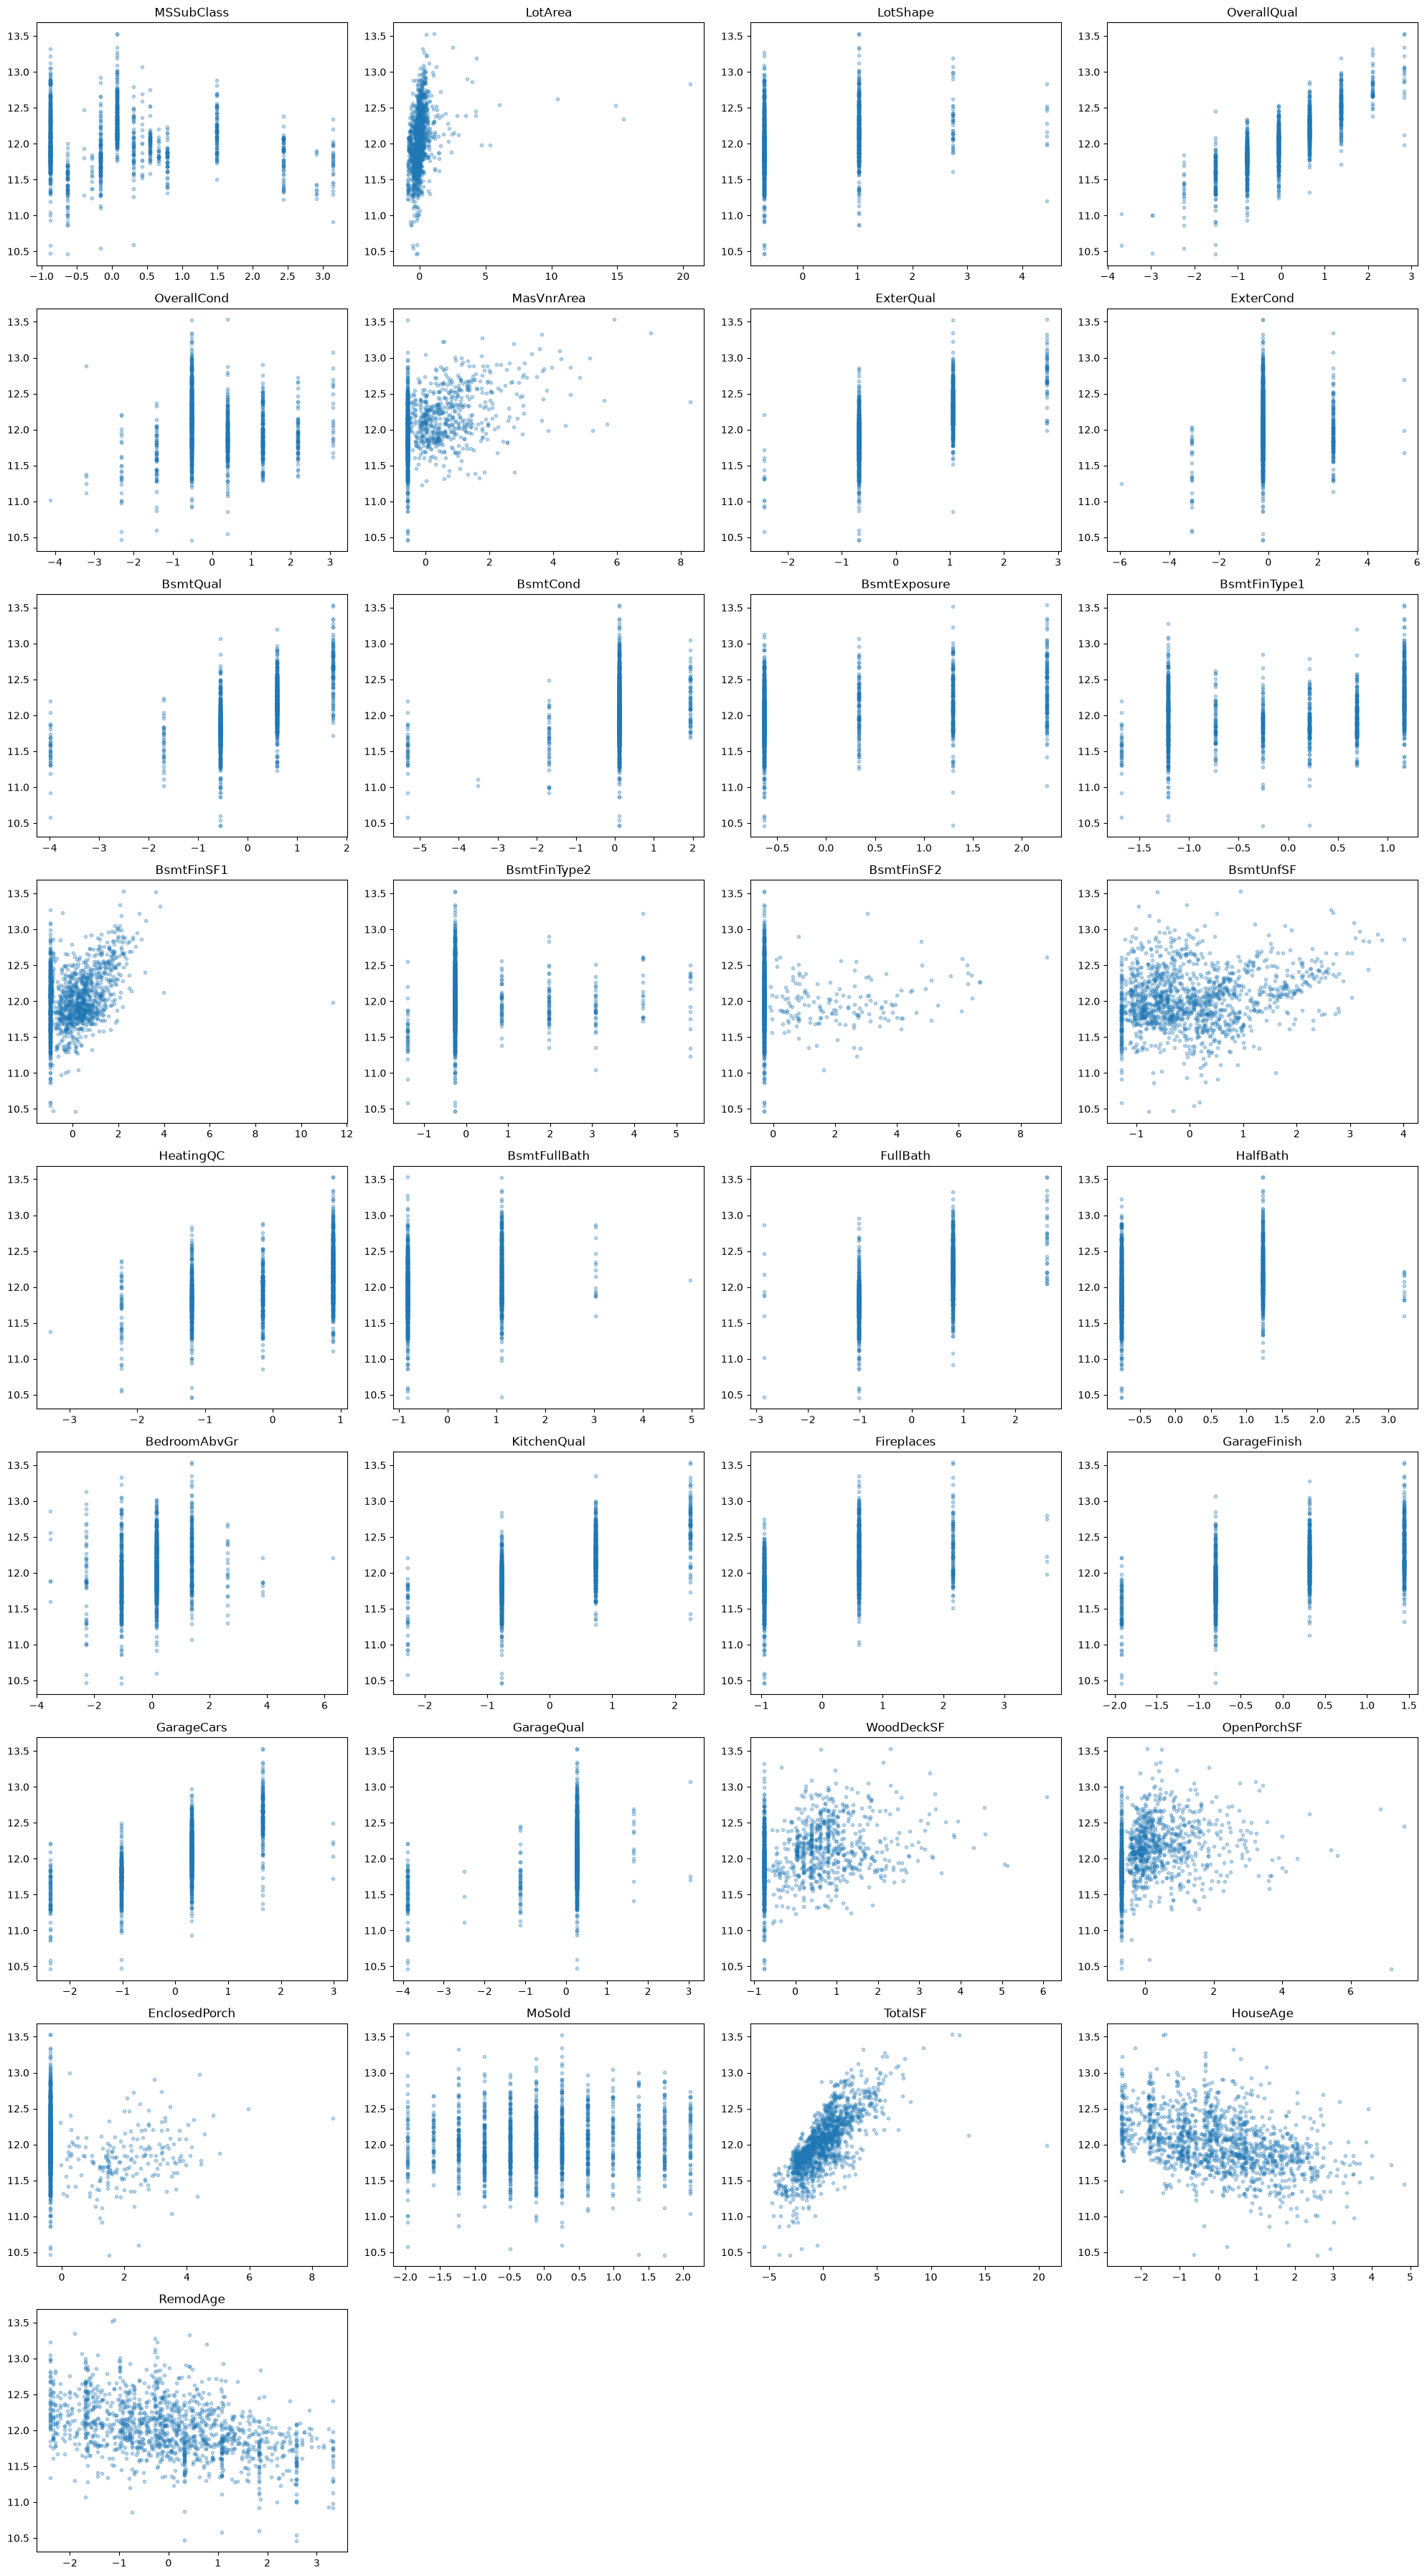

In [50]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.drop("SalePrice")

fig, axes = plt.subplots(nrows=len(numeric_cols)//4 + 1, ncols=4, figsize=(20, 4*(len(numeric_cols)//4 + 1)))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(df[col], df["SalePrice"], alpha=0.3, s=10)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [51]:
#Qual×TotalSF, Qual×GarageArea, Age×Qual)
df["QualOfSQF"] = df["OverallQual"] * df["TotalSF"]
df["QualOfGarageCarSpace"] =  df["OverallQual"] * df["GarageCars"]
df["AgeQual"] =  df["OverallQual"] * df["HouseAge"]

In [52]:
X = df.drop(columns=["SalePrice"])
X = sm.add_constant(X)
y = df["SalePrice"]
final_model_3 = trimming_pct(X, y, 0.05)

In [53]:
final_model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     257.7
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:16:00   Log-Likelihood:                 1025.5
No. Observations:                1460   AIC:                            -1939.
Df Residuals:                    1404   BIC:                            -1643.
Df Model:                          55                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   11.4054      0.047    240.409      0.000      11.312      11.498
MSSubClass              -0.0367      0.005     -6.908      0.000      -0.047      -0.026
LotArea                  0.0155      0.004      3.954      0.000       0.008       0.023
OverallQual              0.0815      0.006     13.087      0.000       0.069       0.094
OverallCond              0.0442      0.004     11.259      0.000       0.037       0.052
BsmtExposure             0.0221      0.004      5.196      0.000       0.014       0.030
BsmtFinType1             0.0177      0.005      3.445      0.001       0.008       0.028
BsmtFinSF1              -0.0241      0.009     -2.568      0.010      -0.042      -0.006
BsmtFinSF2              -0.0093      0.004     -2.111      0.035      -0.018      -0.001
BsmtUnfSF               -0.0332      0.008     -3.904      0.000      -0.050      -0.017
HeatingQC                0.0155      0.004      3.753      0.000       0.007       0.024
BsmtFullBath             0.0165      0.005      3.471      0.001       0.007       0.026
FullBath                 0.0212      0.005      3.974      0.000       0.011       0.032
HalfBath                 0.0169      0.005      3.471      0.001       0.007       0.026
KitchenQual              0.0237      0.005      4.769      0.000       0.014       0.033
Fireplaces               0.0208      0.004      5.216      0.000       0.013       0.029
GarageFinish             0.0142      0.005      2.950      0.003       0.005       0.024
GarageCars               0.0510      0.006      9.148      0.000       0.040       0.062
GarageQual               0.0391      0.010      3.775      0.000       0.019       0.059
WoodDeckSF               0.0108      0.004      3.056      0.002       0.004       0.018
MSZoning_FV              0.4111      0.053      7.719      0.000       0.307       0.516
MSZoning_RH              0.3733      0.052      7.180      0.000       0.271       0.475
MSZoning_RL              0.3898      0.042      9.270      0.000       0.307       0.472
MSZoning_RM              0.3414      0.043      7.978      0.000       0.257       0.425
LandContour_HLS          0.0623      0.025      2.524      0.012       0.014       0.111
LandContour_Low          0.0616      0.028      2.176      0.030       0.006       0.117
LandContour_Lvl          0.0486      0.017      2.881      0.004       0.016       0.082
LotConfig_CulDSac        0.0475      0.014      3.471      0.001       0.021       0.074
Neighborhood_Crawfor     0.1258      0.020      6.393      0.000       0.087       0.164
Neighborhood_Edwards    -0.0568      0.014     -4.129      0.000      -0.084      -0.030
Neighborhood_MeadowV    -0.0707      0.035     -2.043      0.041      -0.139      -0.003
Neighborhood_NoRidge     0.1193      0.022      5.315    